In [109]:
%matplotlib inline 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [110]:
df = pd.read_csv('malta_properties.csv',index_col =[0])
df

,LOCATION,PRICE,TYPE_OF_PROPERTY,POOL,GARAGE,DATE,BEDROOM,SQM
0,BALZAN,152000.0,apartment,No,No,2015,3,NaN
1,GOZO,185000.0,house,No,No,2015,3,NaN
2,GOZO,293000.0,house,Yes,No,2015,3,NaN
3,GOZO,145000.0,maisonette,No,No,2015,3,NaN
4,MARSASCALA,85000.0,apartment,No,No,2015,2,NaN
...,...,...,...,...,...,...,...,...
103848,SWIEQI,375000.0,maisonette,No,Yes,2022,3,NaN
103849,TARXIEN,310000.0,maisonette,No,No,2022,3,NaN
103850,VALLETTA,575000.0,house,No,No,2022,3,NaN
103851,ŻEBBUĠ,245000.0,apartment,No,No,2022,3,NaN


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 103853 entries, 0 to 103852
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LOCATION          103853 non-null  object 
 1   PRICE             103853 non-null  float64
 2   TYPE_OF_PROPERTY  103853 non-null  object 
 3   POOL              103853 non-null  object 
 4   GARAGE            103853 non-null  object 
 5   DATE              103853 non-null  int64  
 6   BEDROOM           103853 non-null  int64  
 7   SQM               19336 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 7.1+ MB


In [112]:
df.describe()

,PRICE,DATE,BEDROOM,SQM
count,1.038530e+05,103853.000000,103853.000000,19336.000000
mean,3.351225e+05,2017.410792,2.877365,200.988260
std,3.761382e+05,2.015268,0.506877,212.879595
min,1.120000e+04,2015.000000,0.000000,20.000000
25%,1.700000e+05,2016.000000,3.000000,125.000000
50%,2.500000e+05,2017.000000,3.000000,160.000000
75%,3.770000e+05,2018.000000,3.000000,210.000000
max,3.500000e+07,2022.000000,7.000000,9500.000000


In [113]:
df['LOCATION'].unique()

array(['BALZAN', 'GOZO', 'MARSASCALA', 'QAWRA', 'SIĠĠIEWI', 'ST PAUL',
       'ST VENERA', "TA' XBIEX", 'TARXIEN', 'ŻEBBUĠ', 'ATTARD',
       'BIRKIRKARA', 'COSPICUA', 'KAPPARA', 'NAXXAR', 'SLIEMA',
       'VALLETTA', 'ŻABBAR', 'BAĦAR IĊ-ĊAGĦAQ', 'BAĦRIJA', 'BIRGUMA',
       'BIRŻEBBUĠA', 'BUĠIBBA', 'DINGLI', 'FGURA', 'FORT CAMBRIDGE',
       'GĦARGĦUR', 'GĦAXAQ', 'GUARDAMANGIA', 'GUDJA', 'GŻIRA', 'ĦAMRUN',
       'IKLIN', 'KALKARA', 'KIRKOP', 'LIJA', 'LUQA', 'MADLIENA',
       'MANIKATA', 'MARSA', 'MARSAXLOKK', 'MELLIEĦA', 'MĠARR', 'MOSTA',
       'MQABBA', 'MSIDA', 'PAOLA', 'PIETÀ', 'PORTOMASO', 'QORMI', 'RABAT',
       'SALINA', 'SAN ĠWANN', 'SENGLEA ', 'SLIEMA ', 'ST JULIANS',
       'SWATAR', 'SWIEQI', 'TAL-IBRAĠ', 'VITTORIOSA', 'XEMXIJA',
       'ŻEBBIEGĦ', 'ŻEJTUN', 'ŻURRIEQ', 'FLORIANA', 'MTARFA', 'QRENDI',
       'SAFI', 'BURMARRAD', 'PEMBROKE', 'XGĦAJRA', 'TIGNÉ POINT',
       'MENSIJA', 'SENGLEA'], dtype=object)

Find locations where most of the properties are on sale

top 15

In [114]:
df['LOCATION'].value_counts()

SLIEMA            7505
GOZO              7381
MOSTA             5239
MARSASCALA        4483
ST JULIANS        4469
                  ... 
MARSA              159
BURMARRAD          153
SAFI               148
SALINA             133
FORT CAMBRIDGE     114
Name: LOCATION, Length: 74, dtype: int64

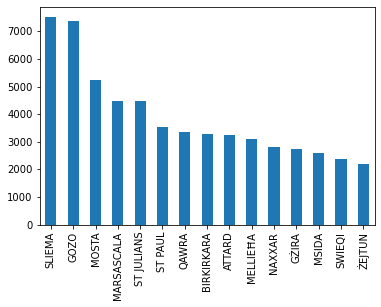

In [115]:
#locs=df['LOCATION'].value_counts().head(10).index.tolist()
df['LOCATION'].value_counts().head(15).plot(kind='bar')
plt.savefig('location_per_sales.png',dpi=300, bbox_inches = "tight")
plt.show()

Find the locations where most of the properties with pools are located

In [116]:
df_pools = df[df['POOL']=='Yes']
df_pools.reset_index(inplace=True)
df_pools

,index,LOCATION,PRICE,TYPE_OF_PROPERTY,POOL,GARAGE,DATE,BEDROOM,SQM
0,2,GOZO,293000.0,house,Yes,No,2015,3,NaN
1,12,ŻEBBUĠ,950000.0,house,Yes,No,2015,3,200.0
2,13,ATTARD,450000.0,villa,Yes,No,2015,3,NaN
3,18,GOZO,99000.0,house,Yes,Yes,2015,3,NaN
4,22,KAPPARA,650000.0,villa,Yes,Yes,2015,3,NaN
...,...,...,...,...,...,...,...,...,...
8205,103825,SIĠĠIEWI,1090000.0,house,Yes,Yes,2022,3,NaN
8206,103835,ST JULIANS,1550000.0,house,Yes,Yes,2022,3,NaN
8207,103836,ST JULIANS,485000.0,apartment,Yes,No,2022,3,NaN
8208,103845,SWIEQI,1300000.0,house,Yes,Yes,2022,3,320.0


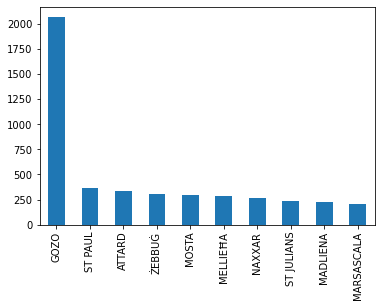

In [117]:
df_pools['LOCATION'].value_counts().head(10).plot(kind='bar')
plt.savefig('pools.png',dpi=300, bbox_inches = "tight")
plt.show()

In [118]:
#trying removing gozo
df_pools_no_gozo =df_pools[df_pools['LOCATION']!='GOZO']
df_pools_no_gozo

,index,LOCATION,PRICE,TYPE_OF_PROPERTY,POOL,GARAGE,DATE,BEDROOM,SQM
1,12,ŻEBBUĠ,950000.0,house,Yes,No,2015,3,200.0
2,13,ATTARD,450000.0,villa,Yes,No,2015,3,NaN
4,22,KAPPARA,650000.0,villa,Yes,Yes,2015,3,NaN
5,25,NAXXAR,875000.0,house,Yes,Yes,2015,3,NaN
6,36,ŻEBBUĠ,950000.0,house,Yes,No,2015,3,200.0
...,...,...,...,...,...,...,...,...,...
8205,103825,SIĠĠIEWI,1090000.0,house,Yes,Yes,2022,3,NaN
8206,103835,ST JULIANS,1550000.0,house,Yes,Yes,2022,3,NaN
8207,103836,ST JULIANS,485000.0,apartment,Yes,No,2022,3,NaN
8208,103845,SWIEQI,1300000.0,house,Yes,Yes,2022,3,320.0


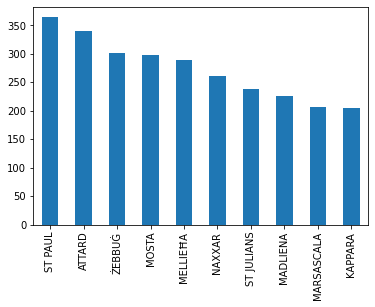

In [119]:
df_pools_no_gozo['LOCATION'].value_counts().head(10).plot(kind='bar')
plt.savefig('pools_no_gozo.png',dpi=300, bbox_inches = "tight")
plt.show()

The prices is increased during the years.

In [120]:
temp=df[df['DATE'] == 2015]
m2015 = temp['PRICE'].mean()
m2015

261488.6566885965

In [121]:
temp=df[df['DATE'] == 2016]
m2016 = temp['PRICE'].mean()
m2016

292334.0164964982

In [123]:
temp=df[df['DATE'] == 2017]
m2017 = temp['PRICE'].mean()
m2017

321127.83200401586

In [124]:
temp=df[df['DATE'] == 2018]
m2018 = temp['PRICE'].mean()
m2018

383900.64053280884

In [125]:
temp=df[df['DATE'] == 2019]
m2019 = temp['PRICE'].mean()
m2019

412598.9177277179

In [126]:
temp=df[df['DATE'] == 2020]
m2020 = temp['PRICE'].mean()
m2020

402683.2349993737

In [127]:
temp=df[df['DATE'] == 2021]
m2021 = temp['PRICE'].mean()
m2021

393598.3685745534

In [128]:
temp=df[df['DATE'] == 2022]
m2022 = temp['PRICE'].mean()
m2022

416865.9942613543

In [129]:
means = [m2015,m2016,m2017,m2018,m2019,m2020,m2021,m2022]
years = [2015,2016,2017,2018,2019,2020,2021,2022]

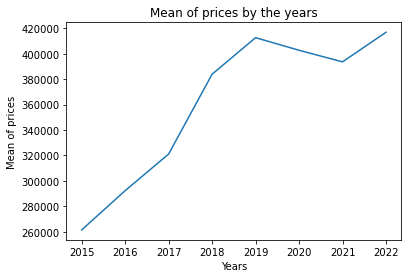

In [130]:
plt.plot(years, means)
plt.title('Mean of prices by the years')
plt.xlabel('Years')
plt.ylabel('Mean of prices')
plt.savefig('prices_per_years.png',dpi=300, bbox_inches = "tight")

We are going to check what properties are more likely to have both a pool and a garage

In [131]:
df['TYPE_OF_PROPERTY'].value_counts()

apartment     47663
house         35976
maisonette    16156
villa          4058
Name: TYPE_OF_PROPERTY, dtype: int64

In [132]:
yes = []
labels = ['apartment','house','maisonette','villa']

yes.append(len(df[(df['TYPE_OF_PROPERTY'] == 'apartment') & (df['GARAGE'] == 'Yes') & (df['POOL'] == 'Yes')]))
                   
yes.append(len(df[(df['TYPE_OF_PROPERTY'] == 'house') & (df['GARAGE'] == 'Yes') & (df['POOL'] == 'Yes')]))
                   
yes.append(len(df[(df['TYPE_OF_PROPERTY'] == 'maisonette') & (df['GARAGE'] == 'Yes') & (df['POOL'] == 'Yes')]))

yes.append(len(df[(df['TYPE_OF_PROPERTY'] == 'villa') & (df['GARAGE'] == 'Yes') & (df['POOL'] == 'Yes')]))                   

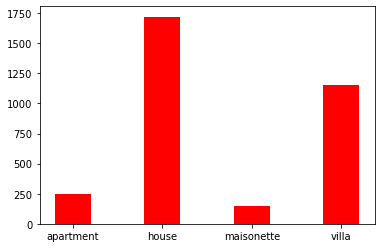

In [133]:
plt.bar(labels,yes,0.4,color='red')
plt.savefig('garages_pools.png',dpi=300, bbox_inches = "tight")
plt.show()

In [134]:
df['BEDROOM'].value_counts()

3    83434
2    13654
4     4169
1     2105
5      485
0        5
7        1
Name: BEDROOM, dtype: int64

In [135]:
stats.pearsonr(df['PRICE'], df['BEDROOM']) #p-value = 0. Hence, no correlation

(0.16477367194637987, 0.0)

In [136]:
no_miss_sqm = df[df['SQM'].notna()]
no_miss_sqm.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 19336 entries, 12 to 103846
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   LOCATION          19336 non-null  object 
 1   PRICE             19336 non-null  float64
 2   TYPE_OF_PROPERTY  19336 non-null  object 
 3   POOL              19336 non-null  object 
 4   GARAGE            19336 non-null  object 
 5   DATE              19336 non-null  int64  
 6   BEDROOM           19336 non-null  int64  
 7   SQM               19336 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 1.3+ MB


In [137]:
stats.pearsonr(no_miss_sqm['PRICE'], no_miss_sqm['BEDROOM']) 

(0.14250132623060643, 2.968589770007558e-88)

P-value less than 0.05. Hence,there is signficant correlation. The statistical value is weak and positive.

Let's try with pool and sqm

In [138]:
no_miss_sqm

,LOCATION,PRICE,TYPE_OF_PROPERTY,POOL,GARAGE,DATE,BEDROOM,SQM
12,ŻEBBUĠ,950000.0,house,Yes,No,2015,3,200.0
26,SLIEMA,220000.0,apartment,No,No,2015,3,175.0
31,TA' XBIEX,850000.0,apartment,No,Yes,2015,3,270.0
36,ŻEBBUĠ,950000.0,house,Yes,No,2015,3,200.0
55,ATTARD,130000.0,maisonette,No,No,2015,3,130.0
...,...,...,...,...,...,...,...,...
103821,QORMI,350000.0,maisonette,No,Yes,2022,3,150.0
103827,SLIEMA,350000.0,apartment,No,No,2022,2,115.0
103829,SLIEMA,499000.0,apartment,No,No,2022,3,175.0
103845,SWIEQI,1300000.0,house,Yes,Yes,2022,3,320.0


In [139]:
no_miss_sqm['POOL'] = no_miss_sqm['POOL'].map({'Yes': 1, 'No': 0})
no_miss_sqm['POOL'] = no_miss_sqm['POOL'].astype(int)

<ipython-input-139-809d25399499>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_miss_sqm['POOL'] = no_miss_sqm['POOL'].map({'Yes': 1, 'No': 0})
<ipython-input-139-809d25399499>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_miss_sqm['POOL'] = no_miss_sqm['POOL'].astype(int)


In [140]:
stats.pointbiserialr(no_miss_sqm['POOL'], no_miss_sqm['SQM'])

PointbiserialrResult(correlation=0.25660859385294754, pvalue=2.3754903316015802e-288)